# RM294 Optimization
## Group Project : Marketing Budget Allocation using Linear Programming

**Group:** 4

**Team Members:**
- Saad Salim
- Eunju Kim
- Heidi Momin
- Grace(Peiwei) Ho

In [20]:
!pip install gurobipy

In [35]:
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt

In [22]:
## Uncomment the following lines if needed

from google.colab import files
uploaded = files.upload()



Saving ROI_data.csv to ROI_data (1).csv
Saving roi_mat.csv to roi_mat (1).csv


In [23]:
# ============================================================
# READ ROI DATA FILES
# ============================================================

roi_data = pd.read_csv("ROI_data.csv")
roi_mat = pd.read_csv("roi_mat.csv")

In [24]:
print("ROI Data")
display(roi_data)

print("\nROI Matrix")
display(roi_mat)

ROI Data


,Platform,Print,TV,SEO,AdWords,Facebook,LinkedIn,Instagram,Snapchat,Twitter,Email
0,ROI,0.031,0.049,0.024,0.039,0.016,0.024,0.046,0.026,0.033,0.044
1,Second Firms ROI Estimate,0.049,0.023,0.024,0.039,0.044,0.046,0.026,0.019,0.037,0.026



ROI Matrix


,Unnamed: 0,Print,TV,SEO,AdWords,Facebook,LinkedIn,Instagram,Snapchat,Twitter,Email
0,January,4.0,3.6,2.4,3.9,3.0,3.5,3.6,2.25,3.5,3.5
1,February,4.0,3.9,2.7,3.8,4.3,3.2,2.7,1.80,3.7,3.5
2,March,3.5,2.9,3.1,3.8,2.4,4.1,3.7,2.60,4.2,2.5
3,April,3.8,3.1,2.4,4.4,2.4,3.8,3.7,2.50,3.6,2.9
4,May,3.5,3.2,1.9,3.4,2.7,2.7,3.9,2.20,4.5,3.9
5,June,4.0,3.2,2.7,3.4,3.4,3.0,4.5,2.10,3.8,4.1
6,July,3.9,3.6,2.0,4.4,3.9,3.7,4.3,1.80,4.0,3.8
7,August,4.2,3.3,2.8,4.2,2.0,3.7,3.6,1.50,4.4,4.3
8,September,4.1,2.8,2.5,4.2,2.9,3.7,2.8,2.50,4.0,3.4
9,October,3.0,3.0,3.1,4.6,3.1,3.3,3.2,2.30,2.5,3.2


In [25]:
# Get platform names dynamically
platforms = list(roi_data.columns[1:])

# Set first column as the row label
roi_lookup = roi_data.set_index(roi_data.columns[0])

# Pull ROI rows by label instead of row position
roi_1 = roi_lookup.loc["ROI", platforms].astype(float).to_dict()
roi_2 = roi_lookup.loc["Second Firms ROI Estimate", platforms].astype(float).to_dict()

In [26]:
def solve_marketing_lp(roi_values, platforms, budget=10_000_000, max_per_platform=3_000_000):

    model = gp.Model("Marketing_Budget_Allocation")
    model.setParam("OutputFlag", 0)

    x = model.addVars(
        platforms,
        lb=0,
        ub=max_per_platform,
        vtype=GRB.CONTINUOUS,
        name="Spend"
    )

    model.setObjective(
        gp.quicksum(roi_values[p] * x[p] for p in platforms),
        GRB.MAXIMIZE
    )

    # Spend full budget
    model.addConstr(
        gp.quicksum(x[p] for p in platforms) == budget,
        name="Total_Budget"
    )

    model.addConstr(
        x["Print"] + x["TV"] <= x["Facebook"] + x["Email"],
        name="Traditional_vs_Direct"
    )

    social_media = ["Facebook", "LinkedIn", "Instagram", "Snapchat", "Twitter"]

    model.addConstr(
        gp.quicksum(x[p] for p in social_media) >= 2 * (x["SEO"] + x["AdWords"]),
        name="Social_Media_Minimum"
    )

    model.optimize()

    allocation_df = pd.DataFrame({
        "Platform": platforms,
        "Spend": [x[p].X for p in platforms],
        "ROI": [roi_values[p] for p in platforms],
        "Expected_Return": [roi_values[p] * x[p].X for p in platforms]
    })

    return allocation_df, model.objVal, model, x

In [27]:
# Call it
allocation_1, objective_1, model_1, x_1 = solve_marketing_lp(roi_1, platforms)

display(allocation_1)
print(f"Optimal expected return: ${objective_1:,.2f}")
print(f"Total budget used: ${allocation_1['Spend'].sum():,.2f}")

,Platform,Spend,ROI,Expected_Return
0,Print,0.0,0.031,0.0
1,TV,3000000.0,0.049,147000.0
2,SEO,0.0,0.024,0.0
3,AdWords,1000000.0,0.039,39000.0
4,Facebook,0.0,0.016,0.0
5,LinkedIn,0.0,0.024,0.0
6,Instagram,3000000.0,0.046,138000.0
7,Snapchat,0.0,0.026,0.0
8,Twitter,0.0,0.033,0.0
9,Email,3000000.0,0.044,132000.0


Optimal expected return: $456,000.00
Total budget used: $10,000,000.00


## Base Optimization Result

Using the first consulting firm's ROI estimates, the optimal allocation invests the full \$10 million marketing budget across four advertising platforms: TV, AdWords, Instagram, and Email. TV, Instagram, and Email each receive the maximum allowable investment of \$3 million, while AdWords receives the remaining \$1 million. This allocation produces an expected return of \$456,000, representing a 4.56% return on the total marketing budget.

## Constraint Verification

The optimal solution satisfies all management constraints. The entire \$10 million budget is allocated, and no individual platform exceeds the \$3 million investment limit. The constraint requiring spending on Print and TV to be no greater than spending on Facebook and Email is satisfied at equality (\$3 million on each side), indicating that it is **binding**. The social media spending requirement is satisfied with room to spare, so that constraint is **non-binding** in the optimal solution.

In [28]:
# ============================================================
# TASK 4: Re-optimize using the second ROI estimates
# ============================================================

# The constraints are the same as in Task 3.
# Only the ROI coefficients in the objective function are changed.

allocation_2, objective_2, model_2, x_2 = solve_marketing_lp(roi_2, platforms)

display(allocation_2)

print(f"Optimal expected return using ROI estimate 2: ${objective_2:,.2f}")
print(f"Total budget used: ${allocation_2['Spend'].sum():,.2f}")

,Platform,Spend,ROI,Expected_Return
0,Print,3000000.0,0.049,147000.0
1,TV,0.0,0.023,0.0
2,SEO,0.0,0.024,0.0
3,AdWords,1000000.0,0.039,39000.0
4,Facebook,3000000.0,0.044,132000.0
5,LinkedIn,3000000.0,0.046,138000.0
6,Instagram,0.0,0.026,0.0
7,Snapchat,0.0,0.019,0.0
8,Twitter,0.0,0.037,0.0
9,Email,0.0,0.026,0.0


Optimal expected return using ROI estimate 2: $456,000.00
Total budget used: $10,000,000.00


In [29]:
# Compare the two optimal allocations

allocation_comparison = allocation_1[["Platform", "Spend"]].merge(
    allocation_2[["Platform", "Spend"]],
    on="Platform",
    suffixes=("_ROI1", "_ROI2")
)

allocation_comparison["Change_ROI2_minus_ROI1"] = (
    allocation_comparison["Spend_ROI2"] - allocation_comparison["Spend_ROI1"]
)

display(allocation_comparison)

,Platform,Spend_ROI1,Spend_ROI2,Change_ROI2_minus_ROI1
0,Print,0.0,3000000.0,3000000.0
1,TV,3000000.0,0.0,-3000000.0
2,SEO,0.0,0.0,0.0
3,AdWords,1000000.0,1000000.0,0.0
4,Facebook,0.0,3000000.0,3000000.0
5,LinkedIn,0.0,3000000.0,3000000.0
6,Instagram,3000000.0,0.0,-3000000.0
7,Snapchat,0.0,0.0,0.0
8,Twitter,0.0,0.0,0.0
9,Email,3000000.0,0.0,-3000000.0


In [30]:
# Check whether the two allocations are the same

same_allocation = np.allclose(
    allocation_comparison["Spend_ROI1"],
    allocation_comparison["Spend_ROI2"]
)

print(f"Are the two optimal allocations the same? {same_allocation}")

Are the two optimal allocations the same? False


## Task 4: Re-optimization Under the Second ROI Estimate

We re-solved the same linear programming model using the second consulting firm's ROI estimates. The decision variables and constraints were unchanged, so the feasible region remained the same. The only change was in the objective function, where the ROI coefficients were replaced by the second firm's estimates.

This is an objective-coefficient change rather than a constraint change. The model is still choosing the best feasible allocation from the same feasible region, but the direction of optimization changes when the ROI estimates change.

The optimal allocation under the second ROI estimate is not the same as the allocation under the first ROI estimate. Under the first ROI estimate, the model allocates the budget primarily to TV, AdWords, Instagram, and Email. Under the second ROI estimate, the allocation shifts to Print, AdWords, Facebook, and LinkedIn. This shows that the optimal recommendation is highly sensitive to the ROI coefficients used in the objective function.

In [31]:
# ============================================================
# TASK 5: Opportunity cost of using the wrong ROI estimate
# ============================================================

def allocation_value(allocation, roi):
    total = 0

    for _, row in allocation.iterrows():
        platform = row["Platform"]
        spend = row["Spend"]
        total += spend * roi[platform]

    return total

In [32]:
# Evaluate each allocation under each ROI estimate

value_alloc1_under_roi1 = allocation_value(allocation_1, roi_1)
value_alloc2_under_roi1 = allocation_value(allocation_2, roi_1)

value_alloc2_under_roi2 = allocation_value(allocation_2, roi_2)
value_alloc1_under_roi2 = allocation_value(allocation_1, roi_2)

opportunity_cost_if_roi1_correct = value_alloc1_under_roi1 - value_alloc2_under_roi1
opportunity_cost_if_roi2_correct = value_alloc2_under_roi2 - value_alloc1_under_roi2

print(f"Allocation 1 under ROI 1: ${value_alloc1_under_roi1:,.2f}")
print(f"Allocation 2 under ROI 1: ${value_alloc2_under_roi1:,.2f}")
print(f"Opportunity cost if ROI 1 is correct but Allocation 2 is used: ${opportunity_cost_if_roi1_correct:,.2f}")
print()
print(f"Allocation 2 under ROI 2: ${value_alloc2_under_roi2:,.2f}")
print(f"Allocation 1 under ROI 2: ${value_alloc1_under_roi2:,.2f}")
print(f"Opportunity cost if ROI 2 is correct but Allocation 1 is used: ${opportunity_cost_if_roi2_correct:,.2f}")

Allocation 1 under ROI 1: $456,000.00
Allocation 2 under ROI 1: $252,000.00
Opportunity cost if ROI 1 is correct but Allocation 2 is used: $204,000.00

Allocation 2 under ROI 2: $456,000.00
Allocation 1 under ROI 2: $264,000.00
Opportunity cost if ROI 2 is correct but Allocation 1 is used: $192,000.00


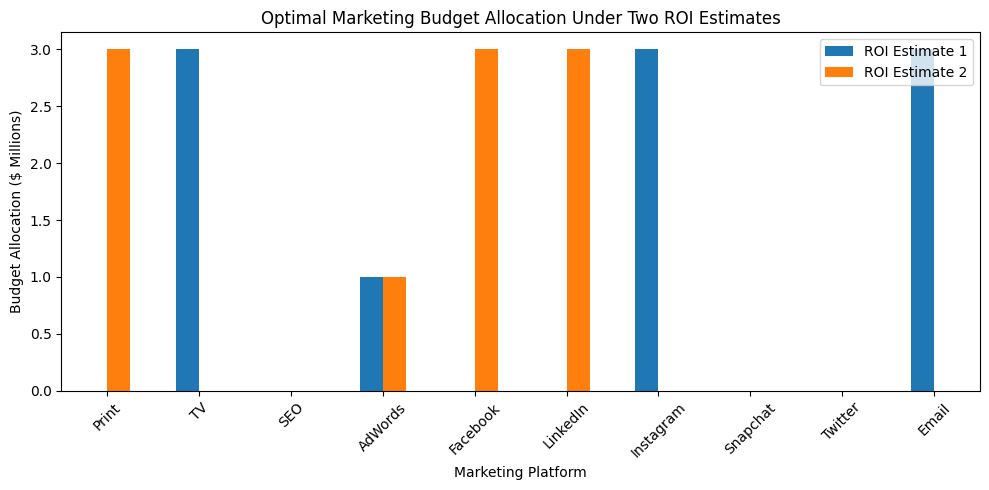

In [36]:
# ============================================================
# GRAPH 1: Compare optimal allocations under ROI estimate 1 and ROI estimate 2
# ============================================================

allocation_plot = allocation_comparison.copy()
allocation_plot["Spend_ROI1_M"] = allocation_plot["Spend_ROI1"] / 1_000_000
allocation_plot["Spend_ROI2_M"] = allocation_plot["Spend_ROI2"] / 1_000_000

ax = allocation_plot.plot(
    x="Platform",
    y=["Spend_ROI1_M", "Spend_ROI2_M"],
    kind="bar",
    figsize=(10, 5)
)

ax.set_title("Optimal Marketing Budget Allocation Under Two ROI Estimates")
ax.set_xlabel("Marketing Platform")
ax.set_ylabel("Budget Allocation ($ Millions)")
ax.legend(["ROI Estimate 1", "ROI Estimate 2"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
# Calculate opportunity costs

loss_if_roi1_true = value_alloc1_under_roi1 - value_alloc2_under_roi1
loss_if_roi2_true = value_alloc2_under_roi2 - value_alloc1_under_roi2

print(f"Loss if ROI 1 is correct but allocation 2 is used: ${loss_if_roi1_true:,.2f}")
print(f"Loss if ROI 2 is correct but allocation 1 is used: ${loss_if_roi2_true:,.2f}")

Loss if ROI 1 is correct but allocation 2 is used: $204,000.00
Loss if ROI 2 is correct but allocation 1 is used: $192,000.00


In [38]:
# Summarize the opportunity cost analysis

opportunity_cost = pd.DataFrame({
    "True_ROI_Scenario": [
        "ROI estimate 1 is correct",
        "ROI estimate 2 is correct"
    ],
    "Optimal_Allocation": [
        "Allocation from ROI estimate 1",
        "Allocation from ROI estimate 2"
    ],
    "Wrong_Allocation_Used": [
        "Allocation from ROI estimate 2",
        "Allocation from ROI estimate 1"
    ],
    "Optimal_Return": [
        value_alloc1_under_roi1,
        value_alloc2_under_roi2
    ],
    "Return_Using_Wrong_Allocation": [
        value_alloc2_under_roi1,
        value_alloc1_under_roi2
    ],
    "Opportunity_Cost": [
        loss_if_roi1_true,
        loss_if_roi2_true
    ]
})

display(opportunity_cost)

,True_ROI_Scenario,Optimal_Allocation,Wrong_Allocation_Used,Optimal_Return,Return_Using_Wrong_Allocation,Opportunity_Cost
0,ROI estimate 1 is correct,Allocation from ROI estimate 1,Allocation from ROI estimate 2,456000.0,252000.0,204000.0
1,ROI estimate 2 is correct,Allocation from ROI estimate 2,Allocation from ROI estimate 1,456000.0,264000.0,192000.0


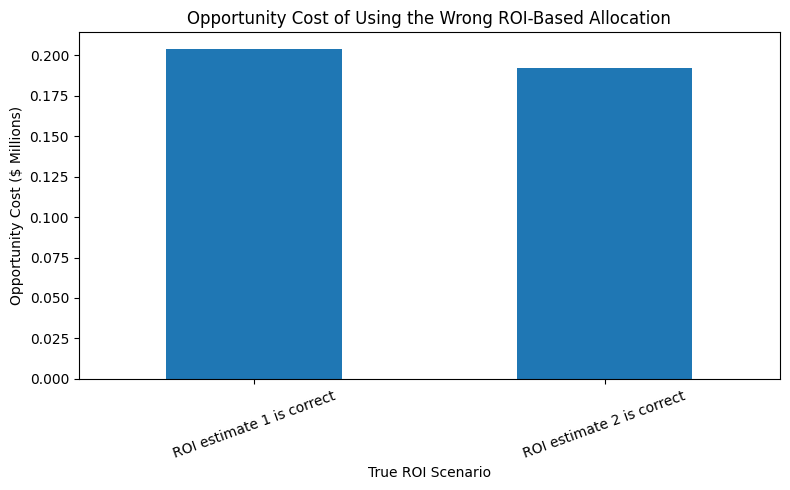

In [41]:
# ============================================================
# GRAPH 2: Opportunity cost of using the wrong allocation
# ============================================================

opp_plot = opportunity_cost.copy()
opp_plot["Opportunity_Cost_M"] = opp_plot["Opportunity_Cost"] / 1_000_000

ax = opp_plot.plot(
    x="True_ROI_Scenario",
    y="Opportunity_Cost_M",
    kind="bar",
    figsize=(8, 5),
    legend=False
)

ax.set_title("Opportunity Cost of Using the Wrong ROI-Based Allocation")
ax.set_xlabel("True ROI Scenario")
ax.set_ylabel("Opportunity Cost ($ Millions)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Task 5: Opportunity Cost of Using the Wrong ROI Estimate
Task 5 evaluates the opportunity cost of choosing the allocation based on the wrong ROI estimate.

Under the first ROI estimates, Allocation 1 is the optimal allocation. Therefore, if the first ROI estimates are correct but we use Allocation 2 instead, the opportunity cost is the difference between the expected return of Allocation 1 and the expected return of Allocation 2 under the first ROI estimates.

Under the second ROI estimates, Allocation 2 is the optimal allocation. Therefore, if the second ROI estimates are correct but we use Allocation 1 instead, the opportunity cost is the difference between the expected return of Allocation 2 and the expected return of Allocation 1 under the second ROI estimates.

This comparison shows how costly it can be to rely on the wrong ROI assumptions when making the marketing budget allocation decision.

In [39]:
# ============================================================
# TASK 6: Sensitivity Analysis of ROI Estimates
# ============================================================


sensitivity = []

for p in platforms:
    sensitivity.append({
        "Platform": p,
        "Current_ROI": roi_1[p],
        "Lowest_ROI_for_Same_Allocation": x_1[p].SAObjLow,
        "Highest_ROI_for_Same_Allocation": x_1[p].SAObjUp,
        "Allowable_Decrease": roi_1[p] - x_1[p].SAObjLow,
        "Allowable_Increase": x_1[p].SAObjUp - roi_1[p]
    })

sensitivity_df = pd.DataFrame(sensitivity)

display(sensitivity_df)

,Platform,Current_ROI,Lowest_ROI_for_Same_Allocation,Highest_ROI_for_Same_Allocation,Allowable_Decrease,Allowable_Increase
0,Print,0.031,-inf,0.049,inf,0.018
1,TV,0.049,0.039,0.062,0.010,0.013
2,SEO,0.024,-inf,0.039,inf,0.015
3,AdWords,0.039,0.033,0.046,0.006,0.007
4,Facebook,0.016,-inf,0.029,inf,0.013
5,LinkedIn,0.024,-inf,0.039,inf,0.015
6,Instagram,0.046,0.039,inf,0.007,inf
7,Snapchat,0.026,-inf,0.039,inf,0.013
8,Twitter,0.033,-inf,0.039,inf,0.006
9,Email,0.044,0.029,inf,0.015,inf


In [40]:
# Display ROI sensitivity values as percentages

sensitivity_percent = sensitivity_df.copy()

roi_cols = [
    "Current_ROI",
    "Lowest_ROI_for_Same_Allocation",
    "Highest_ROI_for_Same_Allocation",
    "Allowable_Decrease",
    "Allowable_Increase"
]

sensitivity_percent[roi_cols] = sensitivity_percent[roi_cols] * 100

display(sensitivity_percent)

,Platform,Current_ROI,Lowest_ROI_for_Same_Allocation,Highest_ROI_for_Same_Allocation,Allowable_Decrease,Allowable_Increase
0,Print,3.1,-inf,4.9,inf,1.8
1,TV,4.9,3.9,6.2,1.0,1.3
2,SEO,2.4,-inf,3.9,inf,1.5
3,AdWords,3.9,3.3,4.6,0.6,0.7
4,Facebook,1.6,-inf,2.9,inf,1.3
5,LinkedIn,2.4,-inf,3.9,inf,1.5
6,Instagram,4.6,3.9,inf,0.7,inf
7,Snapchat,2.6,-inf,3.9,inf,1.3
8,Twitter,3.3,-inf,3.9,inf,0.6
9,Email,4.4,2.9,inf,1.5,inf


## Task 6: Sensitivity Analysis of ROI Estimates


Using the first ROI estimates as the baseline, we performed sensitivity analysis on the objective coefficients of the linear programming model. In this model, each platform's ROI is the objective coefficient for that platform's budget allocation decision variable.

We used Gurobi's SAObjLow and SAObjUp values to identify the range of ROI values over which the optimal allocation from Task 3 remains optimal. The allowable decrease is calculated as the current ROI minus SAObjLow, and the allowable increase is calculated as SAObjUp minus the current ROI.

This analysis helps identify which ROI estimates are most important to validate. A narrow allowable range means the optimal allocation is sensitive to that platform's ROI estimate, so even a small error in that ROI could change the recommended budget allocation. A wider allowable range means the current recommendation is more robust to changes in that ROI.

Therefore, the platforms with the narrowest allowable ranges should receive the most attention when validating the ROI assumptions.

The sensitivity analysis shows that some platforms have an infinite allowable increase or decrease in ROI. This should not be interpreted as the ROI being literally infinite. Instead, it means that, while all other ROI coefficients remain fixed, the ROI for that platform can change in that direction without altering the current optimal allocation. In the sensitivity graph, these infinite values were capped solely for visualization purposes.


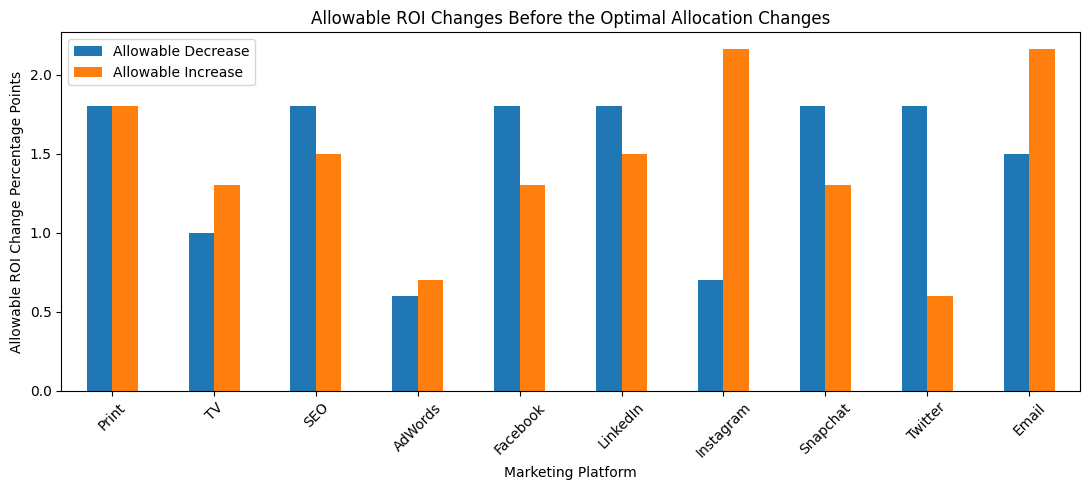

In [42]:
# ============================================================
# GRAPH 3: ROI sensitivity ranges, with infinite values capped for plotting
# ============================================================

sensitivity_plot = sensitivity_percent.copy()

plot_cols = ["Allowable_Decrease", "Allowable_Increase"]

for col in plot_cols:
    finite_max = sensitivity_plot.loc[
        np.isfinite(sensitivity_plot[col]), col
    ].max()

    sensitivity_plot[col] = sensitivity_plot[col].replace(
        [np.inf, -np.inf],
        finite_max * 1.2
    )

ax = sensitivity_plot.plot(
    x="Platform",
    y=plot_cols,
    kind="bar",
    figsize=(11, 5)
)

ax.set_title("Allowable ROI Changes Before the Optimal Allocation Changes")
ax.set_xlabel("Marketing Platform")
ax.set_ylabel("Allowable ROI Change Percentage Points")
ax.legend(["Allowable Decrease", "Allowable Increase"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## TASK 7: Monthly allocation with reinvestment

In [43]:
# ============================================================
# TASK 7: Monthly allocation with reinvestment
# ============================================================

# The monthly ROI matrix stores ROI values as percentages, such as 4.0 for 4%.
# Our optimization function expects ROI as decimals, so we divide each value by 100.

starting_budget = 10_000_000
current_budget = starting_budget
reinvestment_rate = 0.50

month_col = roi_mat.columns[0]

monthly_allocation_list = []
monthly_summary_list = []

for _, row in roi_mat.iterrows():

    month = row[month_col]

    # Convert monthly ROI values from percentages to decimals
    monthly_roi = {
        p: float(row[p]) / 100
        for p in platforms
    }

    # Solve LP for this month using the current available budget
    month_allocation, month_return, month_model, month_x = solve_marketing_lp(
        monthly_roi,
        platforms,
        budget=current_budget
    )

    # Store detailed platform-level allocation
    month_allocation["Month"] = month
    month_allocation["Starting_Budget"] = current_budget
    month_allocation["Total_Expected_Return"] = month_return

    monthly_allocation_list.append(month_allocation)

    # Calculate next month's budget after reinvesting half of the return
    next_budget = current_budget + reinvestment_rate * month_return

    monthly_summary_list.append({
        "Month": month,
        "Starting_Budget": current_budget,
        "Expected_Return": month_return,
        "Reinvested_Amount": reinvestment_rate * month_return,
        "Next_Month_Budget": next_budget,
        "Monthly_ROI": month_return / current_budget
    })

    # Update the budget for the next month
    current_budget = next_budget

monthly_allocations = pd.concat(monthly_allocation_list, ignore_index=True)
monthly_summary = pd.DataFrame(monthly_summary_list)

display(monthly_summary)
display(monthly_allocations)


# Create a cleaner monthly allocation table in millions of dollars

monthly_allocation_pivot = monthly_allocations.pivot(
    index="Month",
    columns="Platform",
    values="Spend"
)

# Keep the original month order from the CSV file
monthly_allocation_pivot = monthly_allocation_pivot.reindex(roi_mat[month_col])

monthly_allocation_pivot_millions = monthly_allocation_pivot / 1_000_000

display(monthly_allocation_pivot_millions.round(3))


,Month,Starting_Budget,Expected_Return,Reinvested_Amount,Next_Month_Budget,Monthly_ROI
0,January,1.000000e+07,373000.000000,186500.000000,1.018650e+07,0.037300
1,February,1.018650e+07,406296.000000,203148.000000,1.038965e+07,0.039886
2,March,1.038965e+07,414416.976000,207208.488000,1.059686e+07,0.039887
3,April,1.059686e+07,414486.833568,207243.416784,1.080410e+07,0.039114
4,May,1.080410e+07,432143.496667,216071.748334,1.102017e+07,0.039998
5,June,1.102017e+07,454766.522818,227383.261409,1.124755e+07,0.041267
6,July,1.124755e+07,468654.641667,234327.320833,1.148188e+07,0.041667
7,August,1.148188e+07,487966.113101,243983.056550,1.172587e+07,0.042499
8,September,1.172587e+07,459219.948447,229609.974223,1.195548e+07,0.039163
9,October,1.195548e+07,427575.208516,213787.604258,1.216926e+07,0.035764


,Platform,Spend,ROI,Expected_Return,Month,Starting_Budget,Total_Expected_Return
0,Print,3.000000e+06,0.040,120000.0,January,1.000000e+07,373000.000000
1,TV,0.000000e+00,0.036,0.0,January,1.000000e+07,373000.000000
2,SEO,0.000000e+00,0.024,0.0,January,1.000000e+07,373000.000000
3,AdWords,1.333333e+06,0.039,52000.0,January,1.000000e+07,373000.000000
4,Facebook,0.000000e+00,0.030,0.0,January,1.000000e+07,373000.000000
...,...,...,...,...,...,...,...
115,LinkedIn,0.000000e+00,0.036,0.0,December,1.242795e+07,516834.174215
116,Instagram,0.000000e+00,0.026,0.0,December,1.242795e+07,516834.174215
117,Snapchat,0.000000e+00,0.029,0.0,December,1.242795e+07,516834.174215
118,Twitter,0.000000e+00,0.036,0.0,December,1.242795e+07,516834.174215


Platform,AdWords,Email,Facebook,Instagram,LinkedIn,Print,SEO,Snapchat,TV,Twitter
Unnamed: 0,,,,,,,,,,
January,1.333,3.000,0.000,2.667,0.000,3.000,0.0,0.0,0.0,0.000
February,2.396,0.000,3.000,0.000,0.000,3.000,0.0,0.0,0.0,1.791
March,3.000,0.000,0.000,1.390,3.000,0.000,0.0,0.0,0.0,3.000
April,3.000,0.000,0.000,3.000,3.000,0.000,0.0,0.0,0.0,1.597
May,0.000,3.000,0.000,3.000,0.000,1.804,0.0,0.0,0.0,3.000
June,0.000,3.000,0.000,3.000,0.000,3.000,0.0,0.0,0.0,2.020
July,3.000,0.000,2.248,3.000,0.000,0.000,0.0,0.0,0.0,3.000
August,1.827,3.000,0.000,0.000,0.655,3.000,0.0,0.0,0.0,3.000
September,3.000,1.363,0.000,0.000,3.000,1.363,0.0,0.0,0.0,3.000


For Task 7, we solved the marketing allocation problem separately for each month using that month’s ROI data. The January budget starts at $10M. After each month, we calculated the expected return from the optimal allocation and reinvested 50% of that return into the next month’s budget. The same business constraints were applied every month. Since the ROI estimates vary by month, the optimal allocation also changes across months.

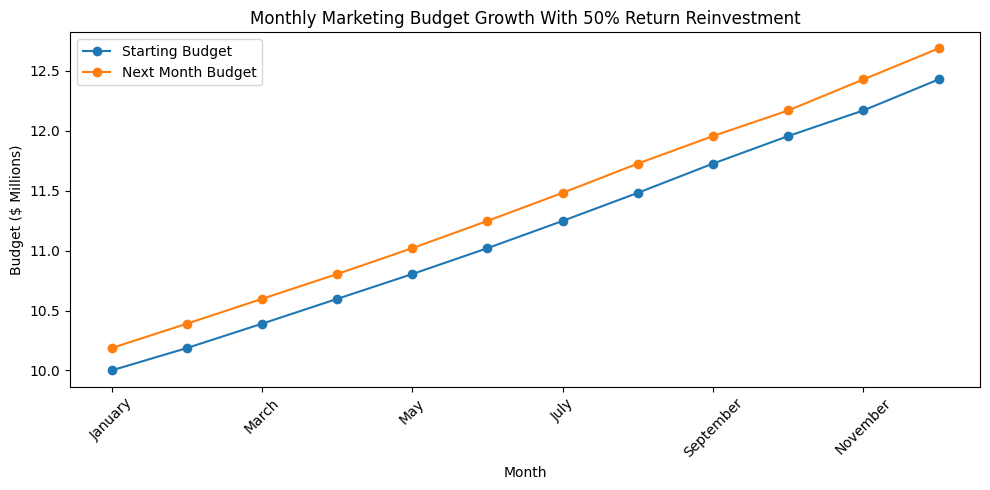

In [44]:
# ============================================================
# GRAPH 4: Monthly budget growth with reinvestment
# ============================================================

budget_plot = monthly_summary.copy()
budget_plot["Starting_Budget_M"] = budget_plot["Starting_Budget"] / 1_000_000
budget_plot["Next_Month_Budget_M"] = budget_plot["Next_Month_Budget"] / 1_000_000

ax = budget_plot.plot(
    x="Month",
    y=["Starting_Budget_M", "Next_Month_Budget_M"],
    kind="line",
    marker="o",
    figsize=(10, 5)
)

ax.set_title("Monthly Marketing Budget Growth With 50% Return Reinvestment")
ax.set_xlabel("Month")
ax.set_ylabel("Budget ($ Millions)")
ax.legend(["Starting Budget", "Next Month Budget"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## TASK 8: Check whether the monthly allocation is stable

In [45]:
# ============================================================
# TASK 8: Check whether the monthly allocation is stable
# ============================================================

# Calculate absolute month-to-month spending changes by platform
monthly_changes = monthly_allocation_pivot.diff().abs()

# Check where the change is greater than $1M
stability_limit = 1_000_000
stability_violations = monthly_changes > stability_limit

is_stable = not stability_violations.iloc[1:].any().any()

print(f"Is the monthly allocation stable? {is_stable}")

# Show monthly changes in millions for readability
monthly_changes_millions = monthly_changes / 1_000_000
display(monthly_changes_millions.round(3))

# List only the violations
violations_list = []

for month in monthly_changes.index[1:]:
    for platform in platforms:
        change_value = monthly_changes.loc[month, platform]

        if change_value > stability_limit:
            violations_list.append({
                "Month": month,
                "Platform": platform,
                "Absolute_Change": change_value,
                "Absolute_Change_Millions": change_value / 1_000_000
            })

violations_df = pd.DataFrame(violations_list)

display(violations_df)


Is the monthly allocation stable? False


Platform,AdWords,Email,Facebook,Instagram,LinkedIn,Print,SEO,Snapchat,TV,Twitter
Unnamed: 0,,,,,,,,,,
January,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
February,1.062,3.000,3.000,2.667,0.000,0.000,0.0,0.0,0.0,1.791
March,0.604,0.000,3.000,1.390,3.000,3.000,0.0,0.0,0.0,1.209
April,0.000,0.000,0.000,1.610,0.000,0.000,0.0,0.0,0.0,1.403
May,3.000,3.000,0.000,0.000,3.000,1.804,0.0,0.0,0.0,1.403
June,0.000,0.000,0.000,0.000,0.000,1.196,0.0,0.0,0.0,0.980
July,3.000,3.000,2.248,0.000,0.000,3.000,0.0,0.0,0.0,0.980
August,1.173,3.000,2.248,3.000,0.655,3.000,0.0,0.0,0.0,0.000
September,1.173,1.637,0.000,0.000,2.345,1.637,0.0,0.0,0.0,0.000


,Month,Platform,Absolute_Change,Absolute_Change_Millions
0,February,AdWords,1.062167e+06,1.062167
1,February,Facebook,3.000000e+06,3.000000
2,February,Instagram,2.666667e+06,2.666667
3,February,Twitter,1.791000e+06,1.791000
4,February,Email,3.000000e+06,3.000000
5,March,Print,3.000000e+06,3.000000
6,March,Facebook,3.000000e+06,3.000000
7,March,LinkedIn,3.000000e+06,3.000000
8,March,Instagram,1.389648e+06,1.389648
9,March,Twitter,1.209000e+06,1.209000


The allocation is not stable because at least one platform has a month-to-month spending change greater than 1M. To model a stable allocation, we would add additional constraints requiring the spending change for each platform between consecutive months to be no more than 1M. This would create a smoother and more realistic marketing plan, but it may reduce the expected return because the model would have less flexibility to shift budget toward the highest-ROI channels each month.

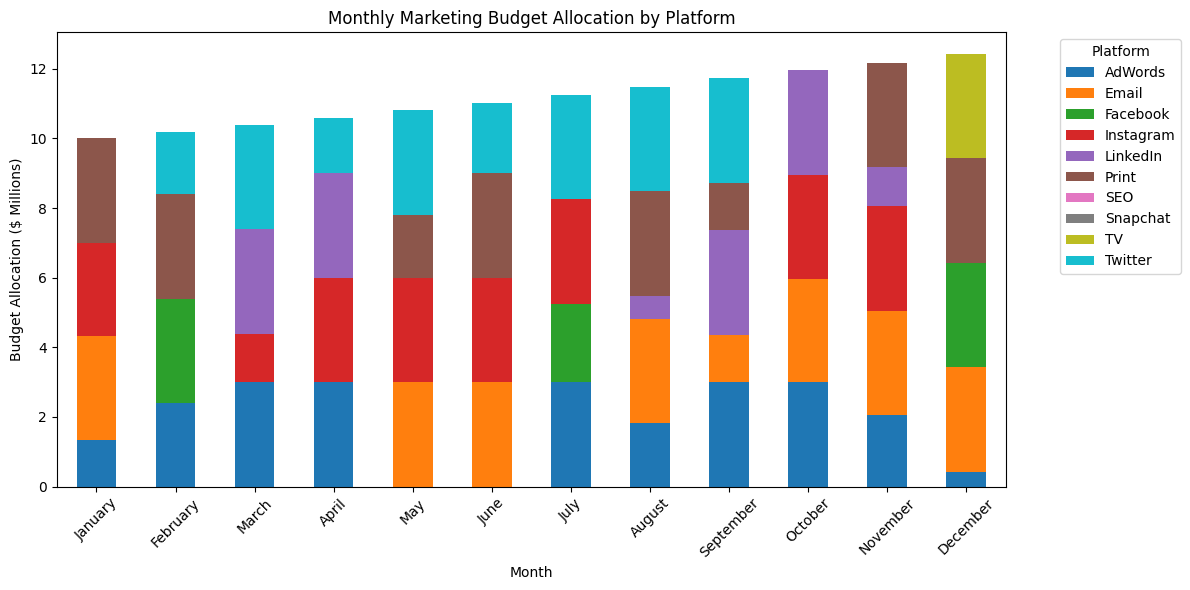

In [46]:
# ============================================================
# GRAPH 5: Monthly platform allocation
# ============================================================

ax = monthly_allocation_pivot_millions.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

ax.set_title("Monthly Marketing Budget Allocation by Platform")
ax.set_xlabel("Month")
ax.set_ylabel("Budget Allocation ($ Millions)")
ax.legend(title="Platform", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()